In [1]:
import pickle
import os, sys
import numpy as np
import pandas as pd
from pathlib import Path
from time import process_time
from collections import defaultdict

from prod_fs import ProD

In [2]:
datasetName = "ANDORcontinuous"
# datasetName = "ADDERcontinuous"
# datasetName = "ANDORdiscrete"
# datasetName = "ADDERdiscrete"
with open(f"{datasetName}_datasets.pkl", "rb") as handle:
    synthetic_datasets = pickle.load(handle)

dsmap = {
    "ANDORcontinuous": "Continuous ANDOR Dataset",
    "ADDERcontinuous": "Continuous ADDER Dataset",
    "ANDORdiscrete": "Discrete ANDOR Dataset",
    "ADDERdiscrete": "Discrete ADDER Dataset"
}

Below are the list of feautures that are relevant, redundant, and correlated. The other features are just noise. For the electrical datasets, they all have 100 total features.

In [3]:
# ANDOR
# - Relevant   : 0, 1, 2, 3
# - Redundant  : 4, 5, 6, 7
# - Correlated : 8, 9
if datasetName[0:5] == "ANDOR":
    relevant_list   = [0, 1, 2, 3]
    redundant_list  = [4, 5, 6, 7]
    correlated_list = [8, 9]
# ADDER
# - Relevant   : 0, 1, 2
# - Redundant  : 3, 4, 5
# - Correlated : 6, 7
elif datasetName[0:5] == "ADDER":
    relevant_list   = [0, 1, 2]
    redundant_list  = [3, 4, 5]
    correlated_list = [6, 7]

# Parameters for success metric according to Canedo, 2012
# Total number of irrelevant features
It = 100 - len(relevant_list)
# Total number of relevant features
Rt = len(relevant_list)
# Alpha
_alpha = min(0.5, Rt/It)

print(f"Total irrelevant features : {It}")
print(f"Total relevant features   : {Rt}")

nRetainedFeatures = 10 # Top 10 % of 100 for the Electrical datasets (Canedo, 2012)

Total irrelevant features : 96
Total relevant features   : 4


In [4]:
# Use powers of 2 from -4 to 4
bandwidth_multipliers = np.logspace(-4, 4, num=9, base=2)
bandwidth_multipliers

array([ 0.0625,  0.125 ,  0.25  ,  0.5   ,  1.    ,  2.    ,  4.    ,
        8.    , 16.    ])

In [5]:
def experiment_loop(bw_method, suffix):
    # === === === ===
    # Carrying out feature selection for each dataset
    # 50 iterations x 3 different number of samples
    bwHeaders = [f"ProD-{suffix}-{bw}" for bw in bandwidth_multipliers]
    
    headersScores = ["feature"] + bwHeaders + ["iteration", "n_obs"]
    scores_df = pd.DataFrame(data=np.zeros((50*3*100, len(headersScores))), columns=headersScores)
    scores_df["feature"] = np.tile(np.arange(0, 100, 1), 150)

    headersRanks = ["rank"] + bwHeaders + ["iteration", "n_obs"]
    rank_df = pd.DataFrame(data=np.zeros((50*3*10, len(headersRanks))), columns=headersRanks)
    rank_df["rank"] = np.tile(np.arange(0, 10, 1), 150)

    for _factor in bandwidth_multipliers:
        # print(f"BW Factor {_factor} ...")
        count = 0
        count_r = 0
        
        for n_obs in synthetic_datasets.keys():
            # print(f"n_obs: {n_obs}")
            n_obs_datasets = synthetic_datasets[n_obs]

            for i in n_obs_datasets.keys():
                # print(f"Iteration {i} ... ")
                X = n_obs_datasets[i]['X']
                y = n_obs_datasets[i]['y']

                prodRanker = ProD(
                    integration_method="trapz", delta=500, bw_method=bw_method, bw_factor=_factor,
                    k=2, n_jobs=-1, mode="release", lower_end=-1.5, upper_end=2.5
                )
                prodRanker.fit(X, y)

                # === === === === === === ===
                # GETTING TOP N FEATURES
                rank_df.loc[count_r:count_r+9, f"ProD-{suffix}-{_factor}"] = prodRanker.get_topnFeatures(nRetainedFeatures)
                rank_df.loc[count_r:count_r+9, "iteration"] = np.repeat([i], 10)
                rank_df.loc[count_r:count_r+9, "n_obs"] = np.repeat([n_obs], 10)
                count_r += 10
            
                scores_df.loc[count:count+99, f"ProD-{suffix}-{_factor}"] = prodRanker.feature_importances_
                scores_df.loc[count:count+99, "iteration"] = np.repeat([i], 100)
                scores_df.loc[count:count+99, "n_obs"] = np.repeat([n_obs], 100)
                count += 100

    return rank_df, scores_df

In [6]:
ranksScott_df, feature_scoresScott_df = experiment_loop("customScott", "Sco")
ranksSilverman_df, feature_scoresSilverman_df = experiment_loop("customSilverman", "Slv")

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Constructing and evaluating the KDEs per class for every feature ... 


In [7]:
# For the Electrical datasets, 10 % of 100 would be 10
nTop = 10

def count_instances_intop10(_top10, _list=[]):
    list_FSS = list(_top10.columns)
    list_FSS.remove("rank")

    count = pd.Series(data=np.zeros(len(list_FSS)), index=list_FSS)

    for i in _top10.index:
        for fss in count.index:
            if _top10.at[i, fss] in _list:
                count.at[fss] += 1

    return count

def check_ifrelevantistop(_top10, _list=[]):
    list_FSS = list(_top10.columns)
    list_FSS.remove("rank")

    _top10_nfirst = _top10.iloc[:len(_list),:]
    relv_atthetop = pd.Series(
        data=[False for i in range(len(list_FSS))], index=list_FSS
    )

    for fss in list_FSS:
        if set(_top10_nfirst[fss].values) == set(_list):
            relv_atthetop[fss] = True

    return relv_atthetop

def calculate_success(_x):
    """
    Calculating the success rate as defined by Canedo, 2012
    """
    success_col = _x / Rt
    IRatio = _alpha * ((nTop - _x) / It)

    return (success_col - IRatio).clip(lower=0.0) * 100

def calculate_success_per_nobs(nobs, groupeddf_relvcount, groupeddf_relvattop):
    relvcount = groupeddf_relvcount.xs(nobs, level=1)
    relvattop = groupeddf_relvattop.xs(nobs, level=1)

    groupeddf_success = relvcount.apply(calculate_success)

    for fss in groupeddf_success.columns:
        for it_ in groupeddf_success.index:
            if relvattop.at[it_, fss]:
                groupeddf_success.at[it_, fss] = 100.0

    return groupeddf_success.mean(), groupeddf_success.std(), list(groupeddf_relvattop.columns)

In [8]:
def calc_suc_mean_sd(ranks_df, nobs):
    # For all iterations of datasets with varying number of samples, count relevant features in the top 10
    groupeddf_relvcount = ranks_df.groupby(["iteration", "n_obs"]).apply(
        count_instances_intop10, _list=relevant_list
    )

    # For all iterations of datasets with varying number of samples, count relevant features at the top
    groupeddf_relvattop = ranks_df.groupby(["iteration", "n_obs"]).apply(
        check_ifrelevantistop, _list=relevant_list
    )
    
    # Return the success rate as defined by Canedo, 2012
    return calculate_success_per_nobs(nobs, groupeddf_relvcount, groupeddf_relvattop)

In [9]:
def populate_table(ranks_df):
    avrsuccess_obs30, sdsuccess_obs30, fss_list = calc_suc_mean_sd(ranks_df, 30)
    avrsuccess_obs50, sdsuccess_obs50, _ = calc_suc_mean_sd(ranks_df, 50)
    avrsuccess_obs70, sdsuccess_obs70, _ = calc_suc_mean_sd(ranks_df, 70)
    
    # Initialize tables
    average_successrate = pd.DataFrame(
        data=np.zeros((3, len(fss_list))), index=[30, 50, 70], columns=fss_list
    )
    sd_successrate = pd.DataFrame(
        data=np.zeros((3, len(fss_list))), index=[30, 50, 70], columns=fss_list
    )
    
    average_successrate.loc[30] = avrsuccess_obs30
    average_successrate.loc[50] = avrsuccess_obs50
    average_successrate.loc[70] = avrsuccess_obs70
    
    sd_successrate.loc[30] = sdsuccess_obs30
    sd_successrate.loc[50] = sdsuccess_obs50
    sd_successrate.loc[70] = sdsuccess_obs70

    return average_successrate, sd_successrate

In [10]:
sucScott_df, sdScott_df = populate_table(ranksScott_df)
sucSilverman_df, sdSilverman_df = populate_table(ranksSilverman_df)

In [11]:
sucScott_df

,ProD-Sco-0.0625,ProD-Sco-0.125,ProD-Sco-0.25,ProD-Sco-0.5,ProD-Sco-1.0,ProD-Sco-2.0,ProD-Sco-4.0,ProD-Sco-8.0,ProD-Sco-16.0
30,15.810764,21.769097,26.250868,34.670139,37.165799,31.682292,15.327257,7.400174,4.429688
50,28.219618,44.696181,64.678819,79.212674,78.711806,73.694444,52.200521,10.361979,2.460938
70,45.663194,61.172743,81.207465,90.223090,90.723958,87.217882,70.188368,10.845486,0.492188


In [12]:
sdScott_df

,ProD-Sco-0.0625,ProD-Sco-0.125,ProD-Sco-0.25,ProD-Sco-0.5,ProD-Sco-1.0,ProD-Sco-2.0,ProD-Sco-4.0,ProD-Sco-8.0,ProD-Sco-16.0
30,17.877109,20.459530,21.535841,20.161683,20.330609,19.520626,19.333597,13.442624,9.550602
50,21.922595,25.203180,19.595481,19.355624,21.647098,22.030759,26.323522,15.059057,7.457767
70,20.424790,20.370505,14.139557,13.280668,13.154782,13.623205,19.391937,14.250494,3.480291


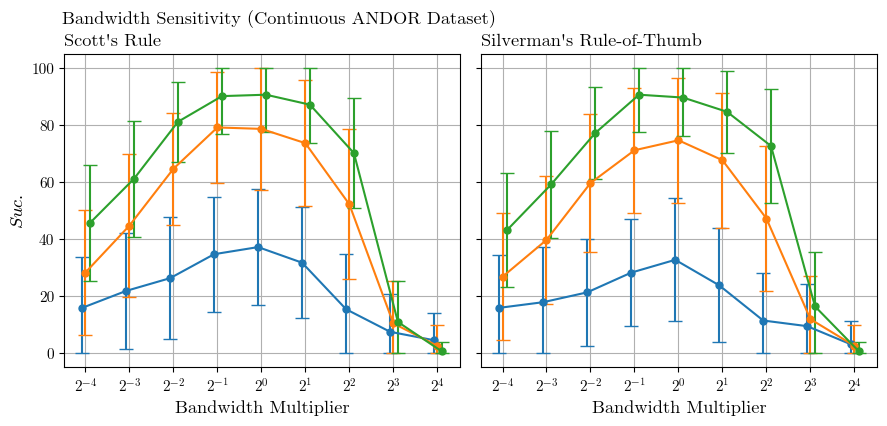

In [13]:
import matplotlib.pyplot as plt

from matplotlib import rc
plt.rcParams['font.serif'] = ['CMU Serif']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.size'] = 11

# Plot parameters
plotlength = 9.0
elinewidth=1.5
capsize=5
markersize=5

# Clip error bars between 0.0 and 100.0
upperCap = lambda x: np.minimum(x, 100.0)
lowerCap = lambda x: np.maximum(x, 0.0)

# Upper and lower bounds (Scott)
upperError_Scott30 = (sucScott_df.loc[30,:] + sdScott_df.loc[30,:]).apply(upperCap) - sucScott_df.loc[30,:]
lowerError_Scott30 = sucScott_df.loc[30,:] - (sucScott_df.loc[30,:] - sdScott_df.loc[30,:]).apply(lowerCap)
upperError_Scott50 = (sucScott_df.loc[50,:] + sdScott_df.loc[50,:]).apply(upperCap) - sucScott_df.loc[50,:]
lowerError_Scott50 = sucScott_df.loc[50,:] - (sucScott_df.loc[50,:] - sdScott_df.loc[50,:]).apply(lowerCap)
upperError_Scott70 = (sucScott_df.loc[70,:] + sdScott_df.loc[70,:]).apply(upperCap) - sucScott_df.loc[70,:]
lowerError_Scott70 = sucScott_df.loc[70,:] - (sucScott_df.loc[70,:] - sdScott_df.loc[70,:]).apply(lowerCap)

# Upper and lower bounds (Silverman)
upperError_Silverman30 = (sucSilverman_df.loc[30,:] + sdSilverman_df.loc[30,:]).apply(upperCap) - sucSilverman_df.loc[30,:]
lowerError_Silverman30 = sucSilverman_df.loc[30,:] - (sucSilverman_df.loc[30,:] - sdSilverman_df.loc[30,:]).apply(lowerCap)
upperError_Silverman50 = (sucSilverman_df.loc[50,:] + sdSilverman_df.loc[50,:]).apply(upperCap) - sucSilverman_df.loc[50,:]
lowerError_Silverman50 = sucSilverman_df.loc[50,:] - (sucSilverman_df.loc[50,:] - sdSilverman_df.loc[50,:]).apply(lowerCap)
upperError_Silverman70 = (sucSilverman_df.loc[70,:] + sdSilverman_df.loc[70,:]).apply(upperCap) - sucSilverman_df.loc[70,:]
lowerError_Silverman70 = sucSilverman_df.loc[70,:] - (sucSilverman_df.loc[70,:] - sdSilverman_df.loc[70,:]).apply(lowerCap)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(plotlength, plotlength/2), sharey=True)

# SCOTT
ax[0].errorbar(
    bandwidth_multipliers*0.95, # N=30 shifts 10% left
    sucScott_df.loc[30,:], 
    yerr=[lowerError_Scott30, upperError_Scott30],
    label="30",
    fmt='-o', elinewidth=elinewidth, capsize=capsize, markersize=markersize
)
ax[0].errorbar(
    bandwidth_multipliers, # N=50 stays centered
    sucScott_df.loc[50,:], 
    yerr=[lowerError_Scott50, upperError_Scott50],
    label="50",
    fmt='-o', elinewidth=elinewidth, capsize=capsize, markersize=markersize
)
ax[0].errorbar(
    bandwidth_multipliers*1.075, # N=70 shifts 10% right
    sucScott_df.loc[70,:], 
    yerr=[lowerError_Scott70, upperError_Scott70],
    label="70",
    fmt='-o', elinewidth=elinewidth, capsize=capsize, markersize=markersize
)
fig.suptitle(
    f"Bandwidth Sensitivity ({dsmap[datasetName]})", 
    fontsize='large', ha="left", x=0.0765, y=0.94
)

ax[0].set_xscale('log', base=2)
ax[0].set_xticks(bandwidth_multipliers)
ax[0].set_title("Scott's Rule", loc='left', fontsize='large')
ax[0].set_ylabel("$Suc.$", fontsize='large')
ax[0].set_xlabel("Bandwidth Multiplier", fontsize='large')
ax[0].grid()

# SILVERMAN
ax[1].errorbar(
    bandwidth_multipliers*0.95, # N=30 shifts 10% left
    sucSilverman_df.loc[30,:], 
    yerr=[lowerError_Silverman30, upperError_Silverman30],
    label="30",
    fmt='-o', elinewidth=elinewidth, capsize=capsize, markersize=markersize
)
ax[1].errorbar(
    bandwidth_multipliers, # N=50 stays centered
    sucSilverman_df.loc[50,:], 
    yerr=[lowerError_Silverman50, upperError_Silverman50],
    label="50",
    fmt='-o', elinewidth=elinewidth, capsize=capsize, markersize=markersize
)
ax[1].errorbar(
    bandwidth_multipliers*1.075, # N=70 shifts 10% right
    sucSilverman_df.loc[70,:], 
    yerr=[lowerError_Silverman70, upperError_Silverman70],
    label="70",
    fmt='-o', elinewidth=elinewidth, capsize=capsize, markersize=markersize
)

ax[1].set_xscale('log', base=2)
ax[1].set_xticks(bandwidth_multipliers)
ax[1].set_title("Silverman's Rule-of-Thumb", loc='left', fontsize='large')
ax[1].set_xlabel("Bandwidth Multiplier", fontsize='large')
ax[1].grid()

fig.tight_layout()
fig.savefig(f"{datasetName}SensitivityAnalysis.eps", format="eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


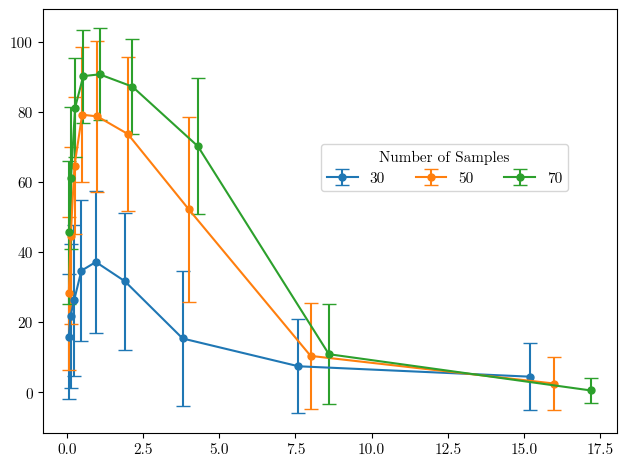

In [16]:
# Lazy way to get legend
plt.figure()
plt.errorbar(
    bandwidth_multipliers*0.95, # N=30 shifts 10% left
    sucScott_df.loc[30,:], 
    yerr=sdScott_df.loc[30,:],
    label="30",
    fmt='-o', elinewidth=elinewidth, capsize=capsize, markersize=markersize
)
plt.errorbar(
    bandwidth_multipliers, # N=50 stays centered
    sucScott_df.loc[50,:], 
    yerr=sdScott_df.loc[50,:],
    label="50",
    fmt='-o', elinewidth=elinewidth, capsize=capsize, markersize=markersize
)
plt.errorbar(
    bandwidth_multipliers*1.075, # N=70 shifts 10% right
    sucScott_df.loc[70,:], 
    yerr=sdScott_df.loc[70,:],
    label="70",
    fmt='-o', elinewidth=elinewidth, capsize=capsize, markersize=markersize
)
plt.legend(title="Number of Samples", ncol=5, loc='upper center', bbox_to_anchor=(0.7, 0.7))
plt.tight_layout()
plt.savefig("Legend.eps", format="eps")